# Name: Zehra Ugurlu

# IDNo.: N01749401

# Lab 4: Time Series Forecasting

## Use the provided data EnergyProduction.csv to answer all the questions in this Notebook

In [42]:
#import the necessary libraries
#Import the libraries here
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

In [43]:
#import the your data here with date as index and properly formatted data type as below:
df = pd.read_csv('./EnergyProduction.csv')
df.head()

,DATE,EnergyIndex
0,1970-01-01,43.0869
1,1970-02-01,42.5577
2,1970-03-01,41.6215
3,1970-04-01,40.1982
4,1970-05-01,39.9321


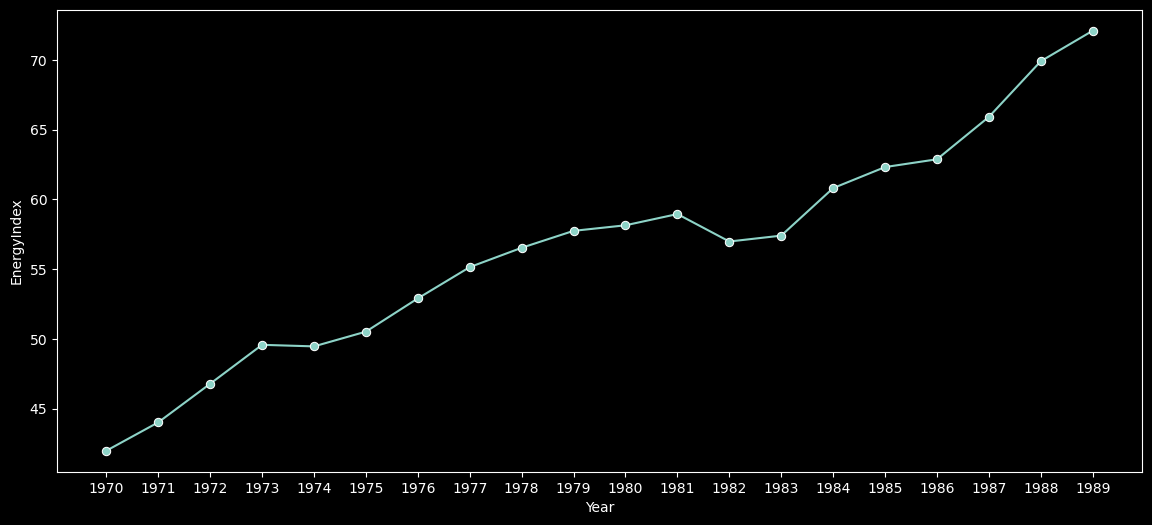

In [44]:
# plot the below plot using the dataset
df["Year"] = pd.to_datetime(df["DATE"]).dt.year

yearly = df.groupby("Year", as_index=False)["EnergyIndex"].mean()

plt.figure(figsize=(14,6))
sns.lineplot(data=yearly, x="Year", y="EnergyIndex", marker="o")

plt.xlabel("Year")
plt.ylabel("EnergyIndex")

plt.xticks(yearly["Year"]) 
plt.show()



In [45]:
# Assign a frequency of 'MS' to the DatetimeIndex as below
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.set_index("DATE")
df = df.asfreq("MS")

print(df.index)

DatetimeIndex(['1970-01-01', '1970-02-01', '1970-03-01', '1970-04-01',
               '1970-05-01', '1970-06-01', '1970-07-01', '1970-08-01',
               '1970-09-01', '1970-10-01',
               ...
               '1989-03-01', '1989-04-01', '1989-05-01', '1989-06-01',
               '1989-07-01', '1989-08-01', '1989-09-01', '1989-10-01',
               '1989-11-01', '1989-12-01'],
              dtype='datetime64[ns]', name='DATE', length=240, freq='MS')


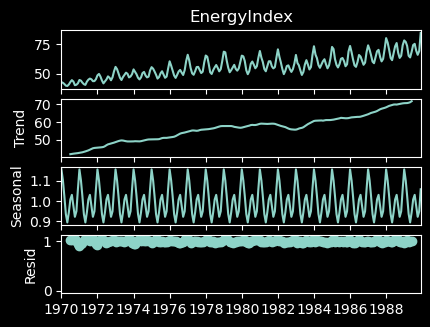

In [46]:
#  Decompose Trend, Cyclic and Error as shown below
result = seasonal_decompose(df["EnergyIndex"], model="multiplicative")

fig = result.plot()
fig.set_size_inches(4,3)
plt.show()

### 4. Change the size of the figure to be more clear.

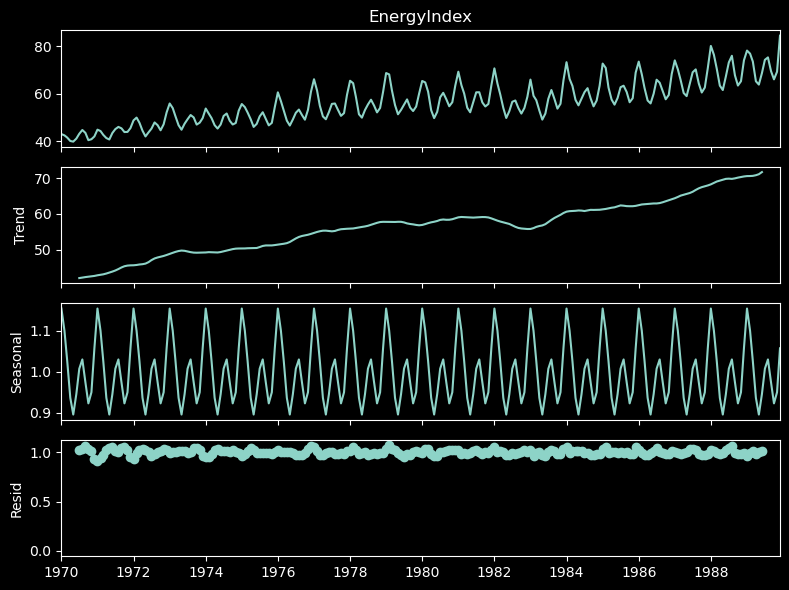

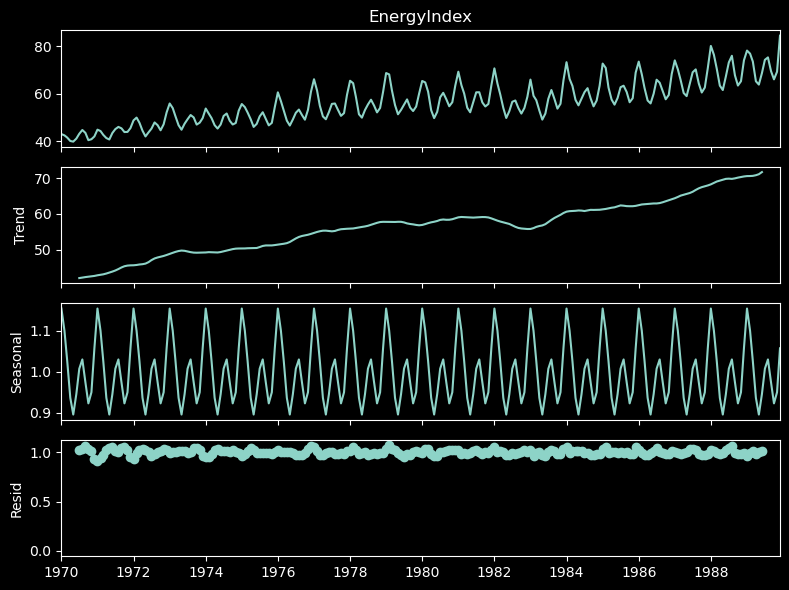

In [48]:
from pylab import rcParams

rcParams["figure.figsize"]= 8,6
result.plot()

### 5. Apply Forcasting on Energy Index

In [49]:
# Apply Forcasting on Energy Index using training data and testing data
y = df["EnergyIndex"]

train = y[:-36]
test = y[-36:]

In [50]:
# fit the training model using exponentialSmoothing within a period of 12 months
from statsmodels.tsa.holtwinters import ExponentialSmoothing

hw_model = ExponentialSmoothing(
    train,
    trend="multiplicative",
    seasonal="multiplicative",
    seasonal_periods=12).fit()

In [51]:
# fit the testing data to 36 months period and rename it to "HW Forecast"
forecast = hw_model.forecast(36)
forecast.name = "HW Forecast"

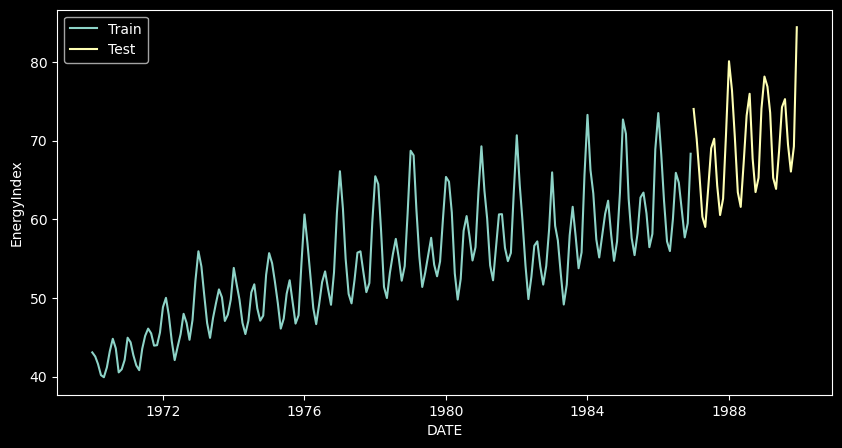

In [63]:
# produce the below plot as shown
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")

plt.xlabel("DATE")
plt.ylabel("EnergyIndex")
plt.legend()
plt.show()

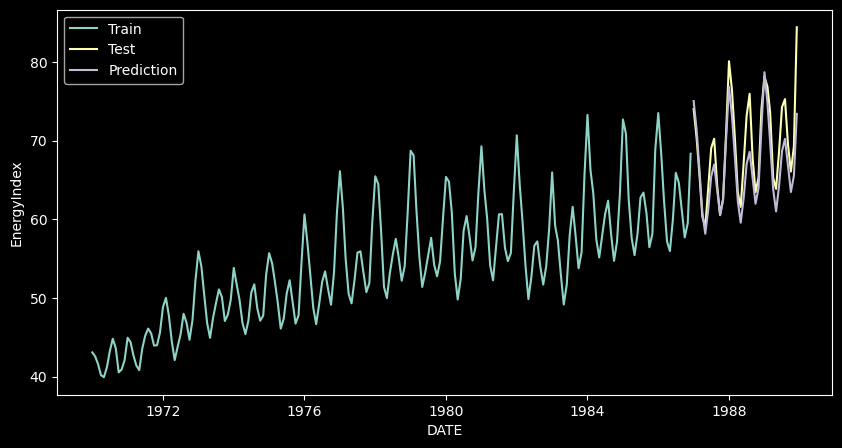

In [ ]:
# produce the below plot as shown
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(forecast.index, forecast, label="Prediction")

plt.xlabel("DATE")
plt.ylabel("EnergyIndex")
plt.legend()
plt.show()

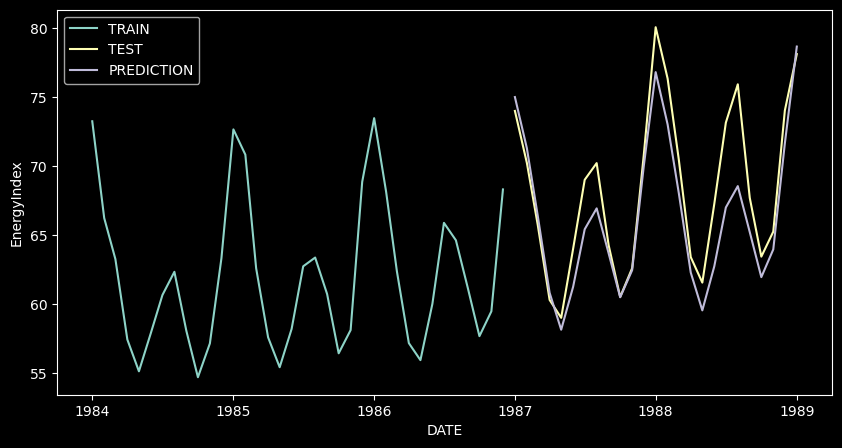

In [67]:
# produce the below plot as shown with specific period of between 1984-01-01 and 1989-01-01

start = "1984-01-01"
end = "1989-01-01"

plt.figure(figsize=(10,5))

plt.plot(train.loc[start:end].index,
         train.loc[start:end],
         label="TRAIN")

plt.plot(test.loc[start:end].index,
         test.loc[start:end],
         label="TEST")

plt.plot(forecast.loc[start:end].index,
         forecast.loc[start:end],
         label="PREDICTION")

plt.xlabel("DATE")
plt.ylabel("EnergyIndex")
plt.legend()
plt.show()

In [ ]:
# Give your conclusion here
# The model correctly depicted the general upward trend and 
# was able to monitor seasonal fluctuations in the dataset to a great extent. 
# The model performed very well during times of frequent fluctuations, 
# and the predicted findings closely matched the actual test data.
